- &#9989; global histogram shapes features for all patients;
- &#9989; vizual flatness/elongation shape features;

In [1]:
import os
import pandas as pd
import numpy as np
import glob
import seaborn as sns
import matplotlib.pyplot as plt

# New features from shape features values (min, max, mean, ...)

In [2]:
# FOR ALL PATIENTS
main_folder_path = r"E:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path).filter(like="shape")

    shape_features_stats = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col]

        shape_features_stats[f"{col}_mean"]   = x.mean()
        shape_features_stats[f"{col}_median"] = x.median()
        shape_features_stats[f"{col}_std"]    = x.std()
        shape_features_stats[f"{col}_var"]    = x.var()
        shape_features_stats[f"{col}_cv"]     = x.std() / x.mean()     # coefficient of variation
        shape_features_stats[f"{col}_range"]  = x.max() - x.min()
        shape_features_stats[f"{col}_min"]    = x.min()
        shape_features_stats[f"{col}_max"]    = x.max()

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)

# Kruskal-Wallis test for STAGE

In [4]:
# KRUSKAL-WALLIS TEST BETWEEN STAGE GROUPS AND SHAPE STATISTIC FEATURES
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Stage']], left_on='patient_id', right_on='Patient ID')

results = []
for feature in numeric_features:

    stage1 = data[data['Stage'] == 1][feature].dropna()
    stage2 = data[data['Stage'] == 2][feature].dropna()
    stage3 = data[data['Stage'] == 3][feature].dropna()

    from scipy.stats import kruskal
    stat, p_value = kruskal(stage1, stage2, stage3)

    results.append({
        "Feature": feature,
        "H_all": stat,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head()

,Feature,H_all,p_value
8,original_shape_Flatness_mean,14.265137,0.000799
9,original_shape_Flatness_median,13.100096,0.001430
1,original_shape_Elongation_median,11.588060,0.003046
0,original_shape_Elongation_mean,11.188244,0.003720
4,original_shape_Elongation_cv,6.592925,0.037014


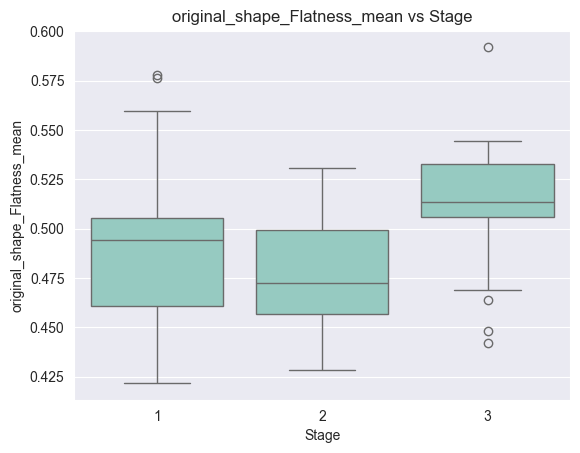

In [6]:
img_feature = "original_shape_Flatness_mean"

sns.set_style("darkgrid")
sns.boxplot(x='Stage', y=img_feature, data=data)
plt.xlabel('Stage')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Stage', fontsize=12)
plt.show()

# Kruskal Wallis test for M-PROTEIN TYPE

In [7]:
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'M-protein type']], left_on='patient_id', right_on='Patient ID')

results = []
for feature in numeric_features:

    stage1 = data[data['M-protein type'] == "IgG"][feature].dropna()
    stage2 = data[data['M-protein type'] == "IgA"][feature].dropna()
    stage3 = data[data['M-protein type'] == "LC only"][feature].dropna()

    from scipy.stats import kruskal
    stat, p_value = kruskal(stage1, stage2, stage3)

    results.append({
        "Feature": feature,
        "H_all": stat,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head()

,Feature,H_all,p_value
76,original_shape_MinorAxisLength_cv,7.893155,0.019321
36,original_shape_Maximum2DDiameterColumn_cv,7.140238,0.028153
75,original_shape_MinorAxisLength_var,6.764775,0.033966
74,original_shape_MinorAxisLength_std,6.764775,0.033966
77,original_shape_MinorAxisLength_range,6.678549,0.035463


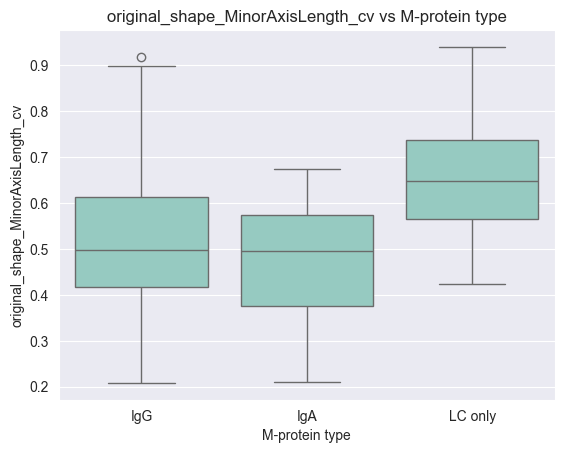

In [9]:
img_feature = "original_shape_MinorAxisLength_cv"

sns.set_style("darkgrid")
sns.boxplot(x='M-protein type', y=img_feature, data=data)
plt.xlabel('M-protein type')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs M-protein type', fontsize=12)
plt.show()

# Spearman's test for B2 MICROGLOBULIN

In [11]:
# SPEARMAN TEST BETWEEN B2-MICROGLOBULIN AND SHAPE STATISTIC FEATURES
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Beta2 microglobulin (mg/l)']], left_on='patient_id', right_on='Patient ID')

results = []
for feature in numeric_features:

    from scipy.stats import spearmanr
    valid_idx = data[feature].notna() & data['Beta2 microglobulin (mg/l)'].notna()
    corr, p_value = spearmanr(data[feature][valid_idx], data['Beta2 microglobulin (mg/l)'][valid_idx])

    results.append({
        "Feature": feature,
        "corr": corr,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head()

,Feature,corr,p_value
8,original_shape_Flatness_mean,0.280938,0.019371
4,original_shape_Elongation_cv,-0.279258,0.020139
16,original_shape_LeastAxisLength_mean,0.269813,0.024958
2,original_shape_Elongation_std,-0.241478,0.045618
3,original_shape_Elongation_var,-0.241478,0.045618


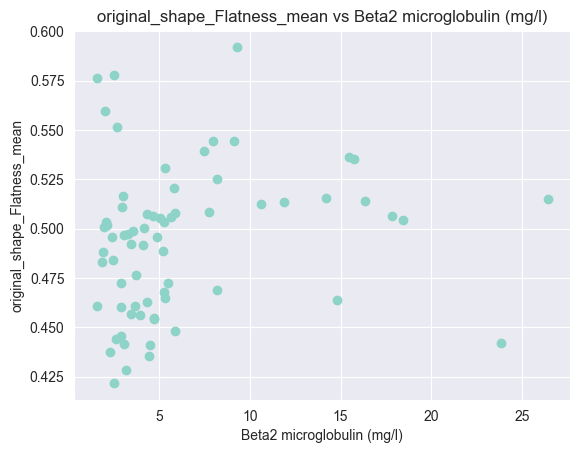

In [12]:
img_feature = "original_shape_Flatness_mean"

plt.scatter(x='Beta2 microglobulin (mg/l)', y=img_feature, data=data)
plt.xlabel('Beta2 microglobulin (mg/l)')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Beta2 microglobulin (mg/l)', fontsize=12)
plt.show()

# Spearman's test for SERUM M-PROTEIN

In [13]:
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Serum M-protein quantity (g/l)']], left_on='patient_id', right_on='Patient ID')

results = []
for feature in numeric_features:

    from scipy.stats import spearmanr
    valid_idx = data[feature].notna() & data['Serum M-protein quantity (g/l)'].notna()
    corr, p_value = spearmanr(data[feature][valid_idx], data['Serum M-protein quantity (g/l)'][valid_idx])

    results.append({
        "Feature": feature,
        "corr": corr,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head()

,Feature,corr,p_value
46,original_shape_Maximum2DDiameterRow_min,-0.198170,0.129058
4,original_shape_Elongation_cv,0.169701,0.194881
81,original_shape_Sphericity_median,-0.162413,0.215038
60,original_shape_Maximum3DDiameter_cv,-0.156125,0.233566
43,original_shape_Maximum2DDiameterRow_var,-0.153622,0.241242


# Shape features distribution

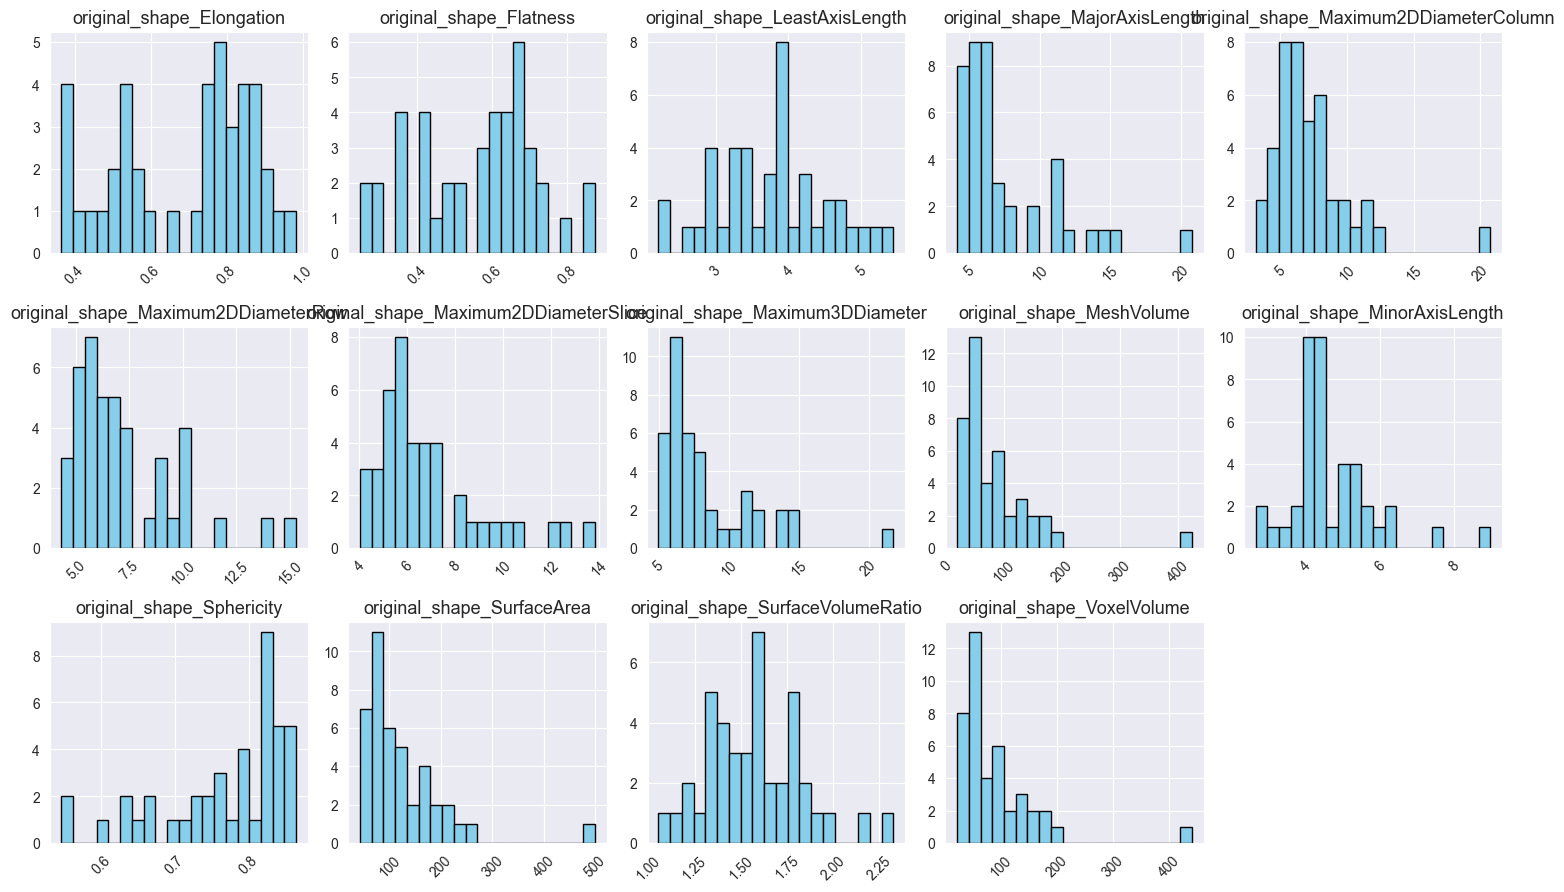

In [10]:
numeric_cols = df.select_dtypes(include=['number']).columns
n_cols = len(numeric_cols)
cols_per_row = 5
rows = (n_cols + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(cols_per_row*3, rows*3))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols_per_row, i+1)
    plt.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(col, fontsize=13)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# New features from distribution (histogram) of every shape feature

In [17]:
# Skewness; Kurtosis; Percentile10, 25, 75, 90; IQR (P75-P25); Entropy;

main_folder_path = r"E:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path).filter(like="shape")

    shape_features_stats = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col].dropna()

        from scipy.stats import skew, kurtosis
        shape_features_stats[f"{col}_skewness"] = skew(x)
        shape_features_stats[f"{col}_kurtosis"] = kurtosis(x)

        shape_features_stats[f"{col}_percentile10"] = x.quantile(0.10)
        shape_features_stats[f"{col}_percentile25"] = x.quantile(0.25)
        shape_features_stats[f"{col}_percentile75"] = x.quantile(0.75)
        shape_features_stats[f"{col}_percentile90"] = x.quantile(0.90)
        shape_features_stats[f"{col}_IQR"] = x.quantile(0.75) - x.quantile(0.25)  # InterQuartileRange (P75-P25)

        hist, _ = np.histogram(x, bins=20)
        hist = hist / hist.sum()
        hist = hist[hist > 0]

        from scipy.stats import entropy
        shape_features_stats[f"{col}_entropy"] = entropy(hist)

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)

# Kruskal-Wallis test for STAGE

In [18]:
# KRUSKAL-WALLIS TEST BETWEEN STAGE GROUPS AND SHAPE STATISTIC FEATURES
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Stage']], left_on='patient_id', right_on='Patient ID')

results = []
for feature in numeric_features:

    stage1 = data[data['Stage'] == 1][feature].dropna()
    stage2 = data[data['Stage'] == 2][feature].dropna()
    stage3 = data[data['Stage'] == 3][feature].dropna()

    from scipy.stats import kruskal
    stat, p_value = kruskal(stage1, stage2, stage3)

    results.append({
        "Feature": feature,
        "H_all": stat,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head()

,Feature,H_all,p_value
12,original_shape_Flatness_percentile75,13.662323,0.001080
3,original_shape_Elongation_percentile25,10.925294,0.004242
19,original_shape_LeastAxisLength_percentile25,9.511207,0.008603
11,original_shape_Flatness_percentile25,9.249902,0.009804
79,original_shape_MinorAxisLength_entropy,9.120021,0.010462


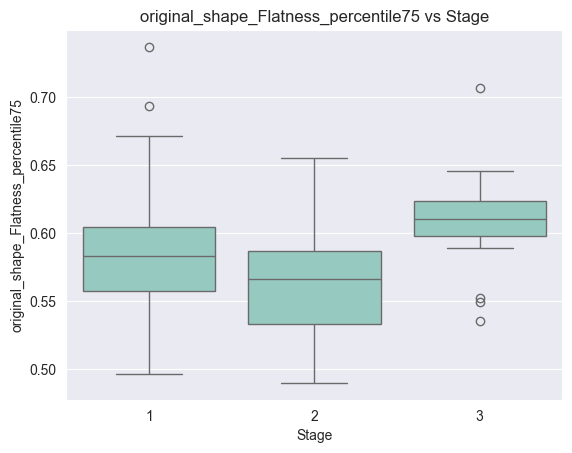

In [19]:
img_feature = "original_shape_Flatness_percentile75"

sns.set_style("darkgrid")
sns.boxplot(x='Stage', y=img_feature, data=data)
plt.xlabel('Stage')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Stage', fontsize=12)
plt.show()

# Kruskal-Wallis test for M-protein type

In [21]:
# Skewness; Kurtosis; Percentile10, 25, 75, 90; IQR (P75-P25); Entropy;

main_folder_path = r"E:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path).filter(like="shape")

    shape_features_stats = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col].dropna()

        from scipy.stats import skew, kurtosis
        shape_features_stats[f"{col}_skewness"] = skew(x)
        shape_features_stats[f"{col}_kurtosis"] = kurtosis(x)

        shape_features_stats[f"{col}_percentile10"] = x.quantile(0.10)
        shape_features_stats[f"{col}_percentile25"] = x.quantile(0.25)
        shape_features_stats[f"{col}_percentile75"] = x.quantile(0.75)
        shape_features_stats[f"{col}_percentile90"] = x.quantile(0.90)
        shape_features_stats[f"{col}_IQR"] = x.quantile(0.75) - x.quantile(0.25)  # InterQuartileRange (P75-P25)

        hist, _ = np.histogram(x, bins=20)
        hist = hist / hist.sum()
        hist = hist[hist > 0]

        from scipy.stats import entropy
        shape_features_stats[f"{col}_entropy"] = entropy(hist)

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)



pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'M-protein type']], left_on='patient_id', right_on='Patient ID')

results = []
for feature in numeric_features:

    stage1 = data[data['M-protein type'] == "IgG"][feature].dropna()
    stage2 = data[data['M-protein type'] == "IgA"][feature].dropna()
    stage3 = data[data['M-protein type'] == "LC only"][feature].dropna()

    from scipy.stats import kruskal
    stat, p_value = kruskal(stage1, stage2, stage3)

    results.append({
        "Feature": feature,
        "H_all": stat,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head()

,Feature,H_all,p_value
98,original_shape_SurfaceVolumeRatio_percentile10,9.216296,0.009970
34,original_shape_Maximum2DDiameterColumn_percent...,8.850024,0.011974
6,original_shape_Elongation_IQR,7.762492,0.020625
84,original_shape_Sphericity_percentile75,7.504066,0.023470
74,original_shape_MinorAxisLength_percentile10,6.848934,0.032567


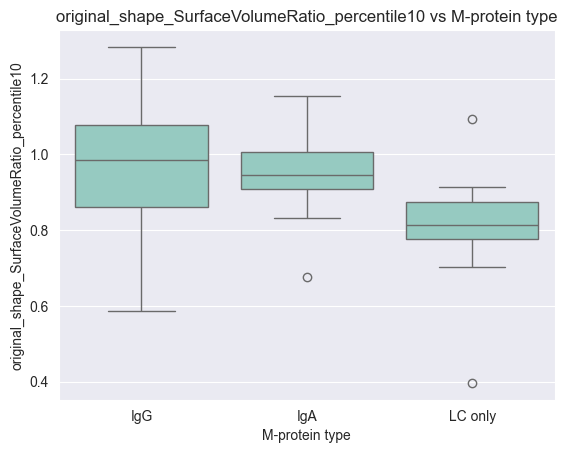

In [22]:
img_feature = "original_shape_SurfaceVolumeRatio_percentile10"

sns.set_style("darkgrid")
sns.boxplot(x='M-protein type', y=img_feature, data=data)
plt.xlabel('M-protein type')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs M-protein type', fontsize=12)
plt.show()

# Spearman's test for B2-microglobulin

In [24]:
# SPEARMAN TEST BETWEEN B2-MICROGLOBULIN AND SHAPE STATISTIC FEATURES
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Beta2 microglobulin (mg/l)']], left_on='patient_id', right_on='Patient ID', how='inner')

results = []
for feature in numeric_features:

    from scipy.stats import spearmanr
    valid_idx = data[feature].notna() & data['Beta2 microglobulin (mg/l)'].notna()
    corr, p_value = spearmanr(data[feature][valid_idx], data['Beta2 microglobulin (mg/l)'][valid_idx])

    results.append({
        "Feature": feature,
        "corr": corr,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head()

,Feature,corr,p_value
21,original_shape_LeastAxisLength_percentile90,0.301144,0.011922
20,original_shape_LeastAxisLength_percentile75,0.276517,0.021448
12,original_shape_Flatness_percentile75,0.261281,0.030118
2,original_shape_Elongation_percentile10,0.255234,0.034294
19,original_shape_LeastAxisLength_percentile25,0.250393,0.037977


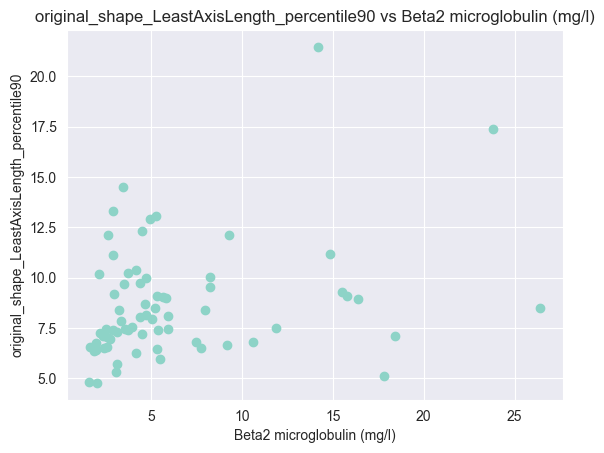

In [25]:
img_feature = "original_shape_LeastAxisLength_percentile90"

plt.scatter(x='Beta2 microglobulin (mg/l)', y=img_feature, data=data)
plt.xlabel('Beta2 microglobulin (mg/l)')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Beta2 microglobulin (mg/l)', fontsize=12)
plt.show()

# Flatness & Elongation images

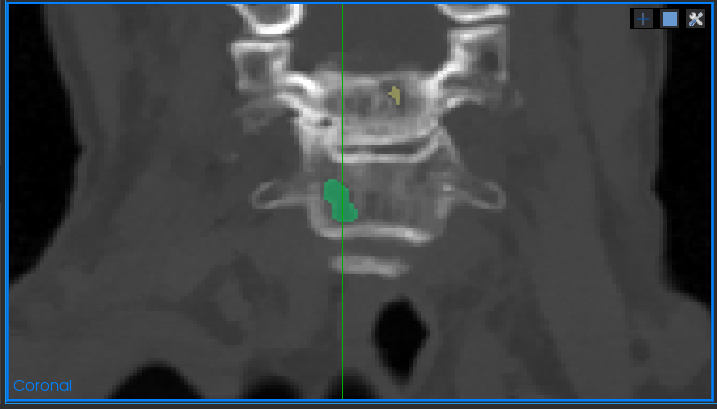 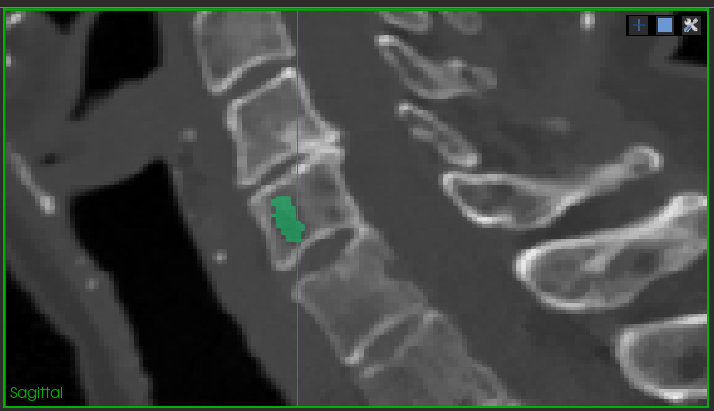
Elongation = 0.96

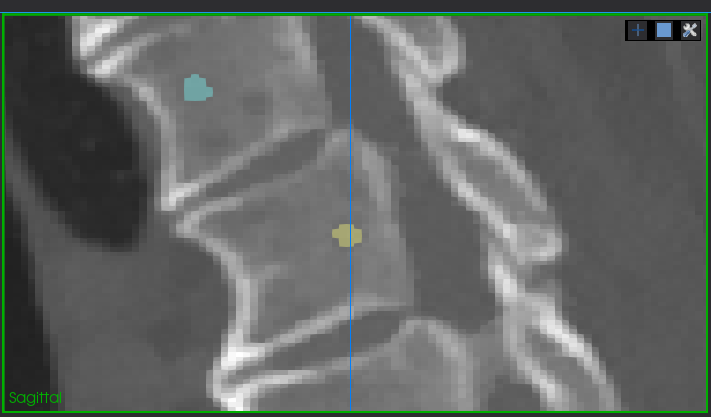 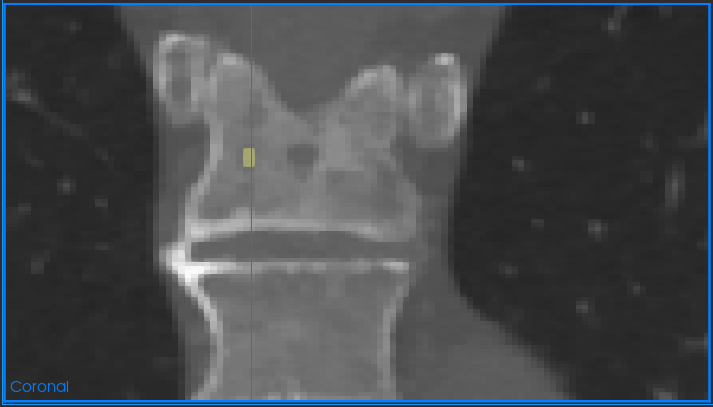
Elongation = 0.55

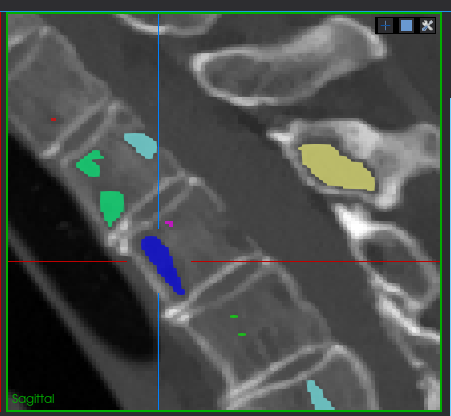
Elongation = 0.37  Flatness = 0.24

Elongation -> Example
- 1.0 – 0.9	takmer guľa
- 0.9 – 0.7	mierne natiahnutá
- 0.7 – 0.5	pretiahnutá
- 0.5 – 0.0	veľmi natiahnutá

Flatness -> Example
- 1.0 - 0.9 guľa
- 0.9 - 0.6 mierne sploštený ovál
- 0.6 - 0.4 plochý disk
- 0.4 - 0.0 veľmi plochá placka

In [42]:
df1 = pd.read_csv(r"E:\DATA_Myelomy\Myel_001\BMD_radiomics_individual_lesion_features.csv").filter(like="shape")
df4 = pd.read_csv(r"E:\DATA_Myelomy\Myel_004\BMD_radiomics_individual_lesion_features.csv").filter(like="shape")

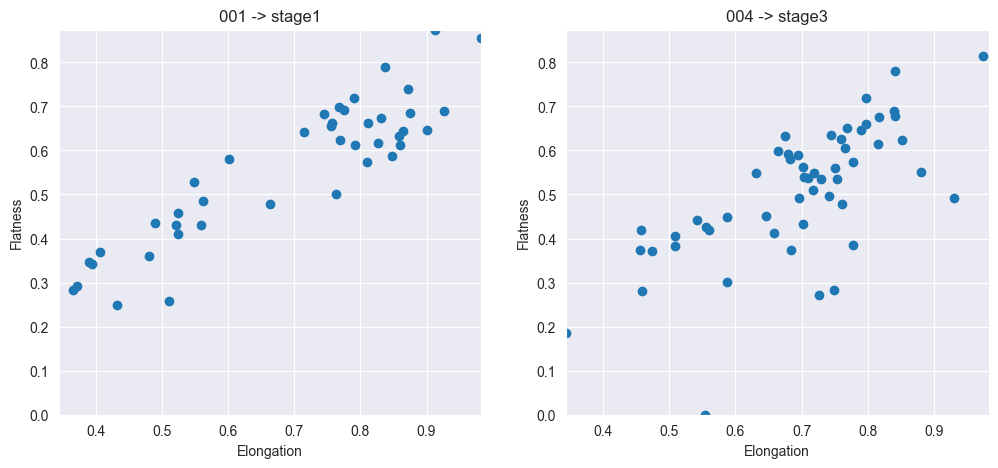

In [43]:
x_min = min(df1["original_shape_Elongation"].min(), df4["original_shape_Elongation"].min())
x_max = max(df1["original_shape_Elongation"].max(), df4["original_shape_Elongation"].max())

y_min = min(df1["original_shape_Flatness"].min(), df4["original_shape_Flatness"].min())
y_max = max(df1["original_shape_Flatness"].max(), df4["original_shape_Flatness"].max())

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.scatter(df1["original_shape_Elongation"], df1["original_shape_Flatness"])
plt.title("001 -> stage1")
plt.xlabel("Elongation")
plt.ylabel("Flatness")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.subplot(122)
plt.scatter(df4["original_shape_Elongation"], df4["original_shape_Flatness"])
plt.title("004 -> stage3")
plt.xlabel("Elongation")
plt.ylabel("Flatness")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.show()

# Boxplots for all patient stage groups

In [1]:
import pandas as pd
from pathlib import Path

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1,'Stage 2': 2,'Stage 3': 3})

stage_groups = clinical_df.groupby('Stage')['Patient ID'].apply(list)
stage_1 = stage_groups.get(1, [])
stage_2 = stage_groups.get(2, [])
stage_3 = stage_groups.get(3, [])

main_path = Path(r"E:\DATA_Myelomy")

def create_stage_df(patient_list):
    all_dfs = []
    for patient_id in patient_list:
        patient_folder = main_path / str(patient_id)

        if patient_folder.exists():
            file_path = next(patient_folder.rglob("*individual_lesion_features.csv*"), None)

            temp_df = pd.read_csv(file_path)
            temp_df['Patient ID'] = patient_id
            all_dfs.append(temp_df)

    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

df_stage_1 = (create_stage_df(stage_1)).filter(like="shape")
df_stage_2 = (create_stage_df(stage_2)).filter(like="shape")
df_stage_3 = (create_stage_df(stage_3)).filter(like="shape")

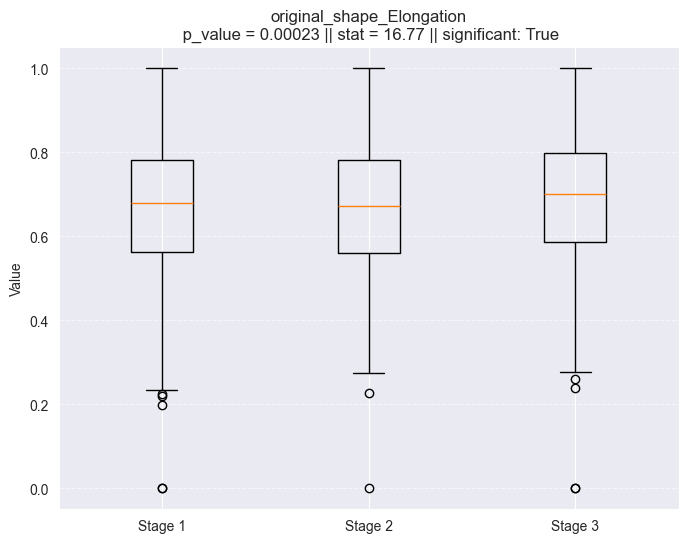

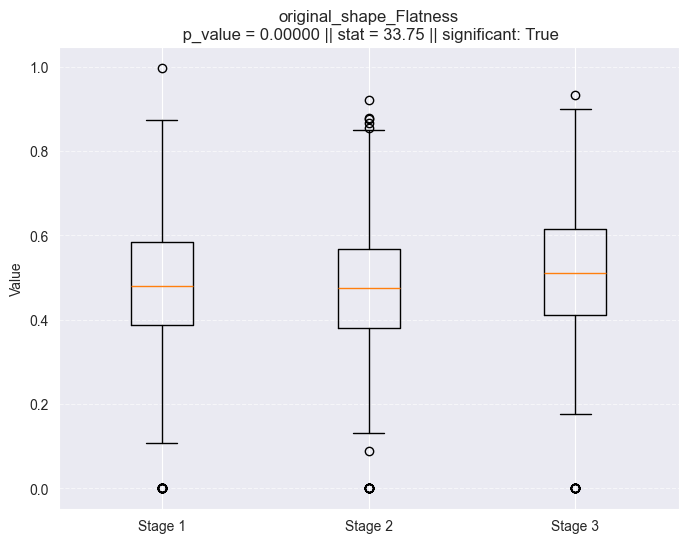

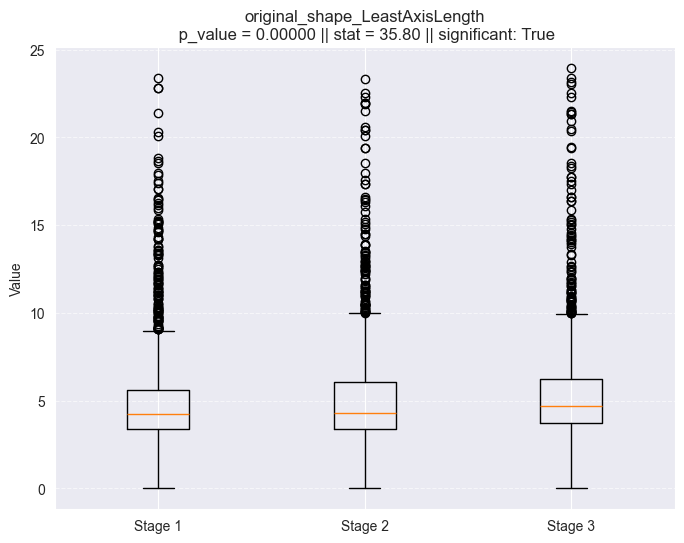

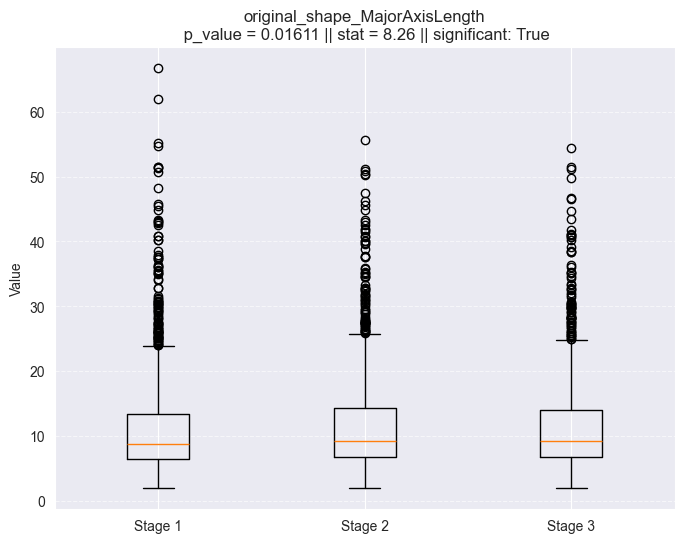

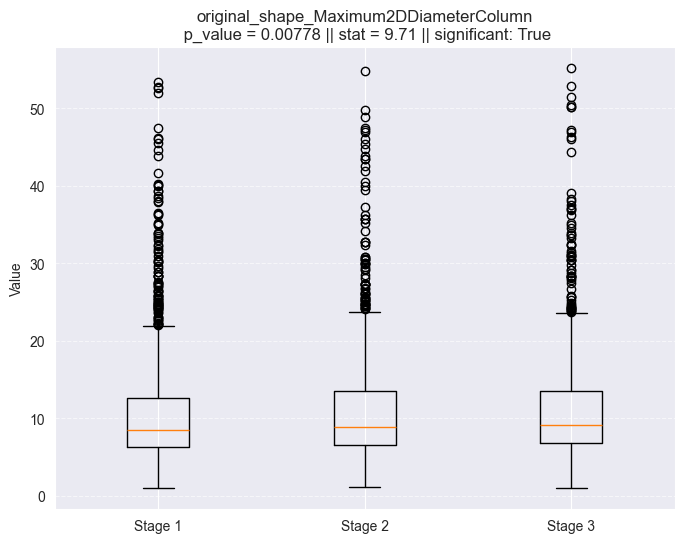

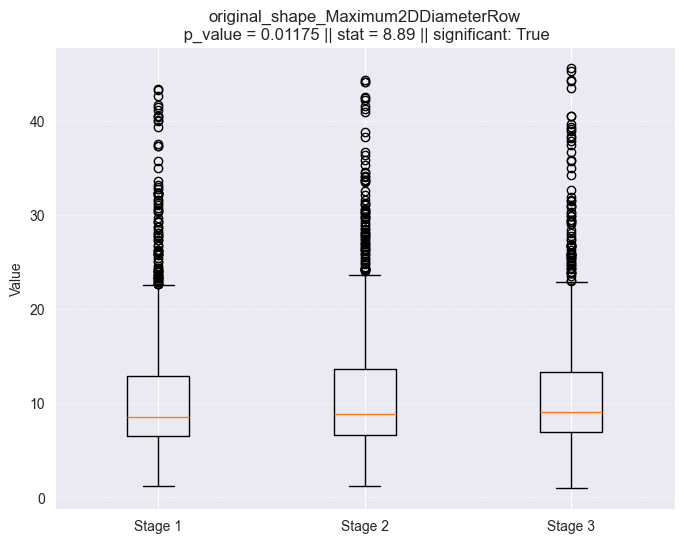

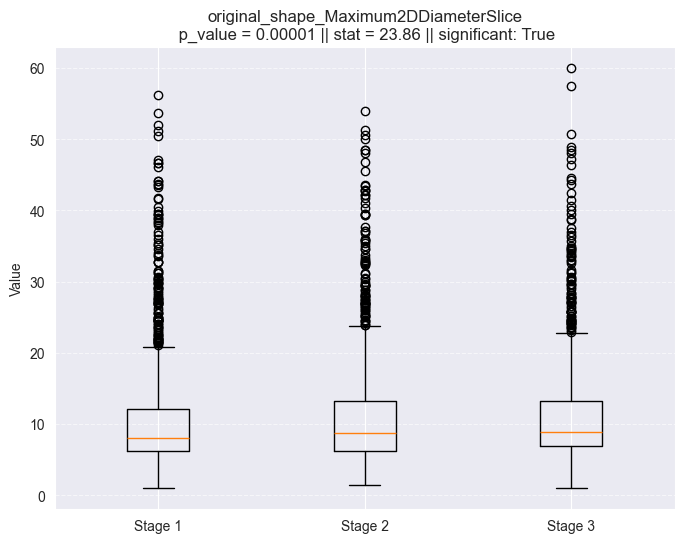

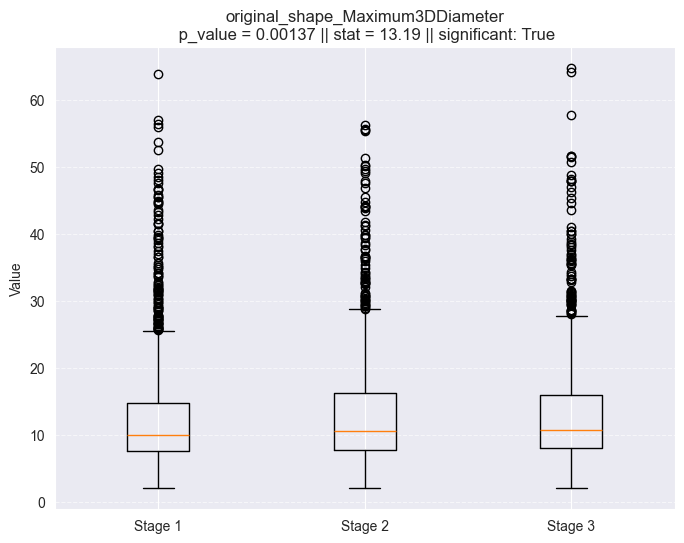

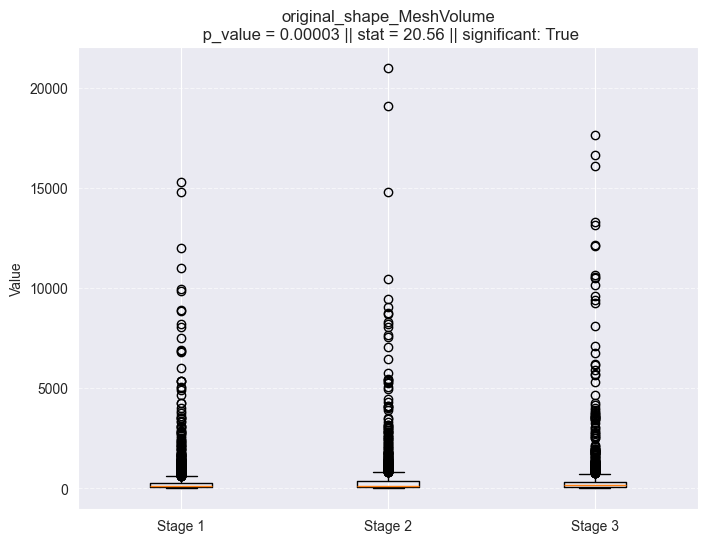

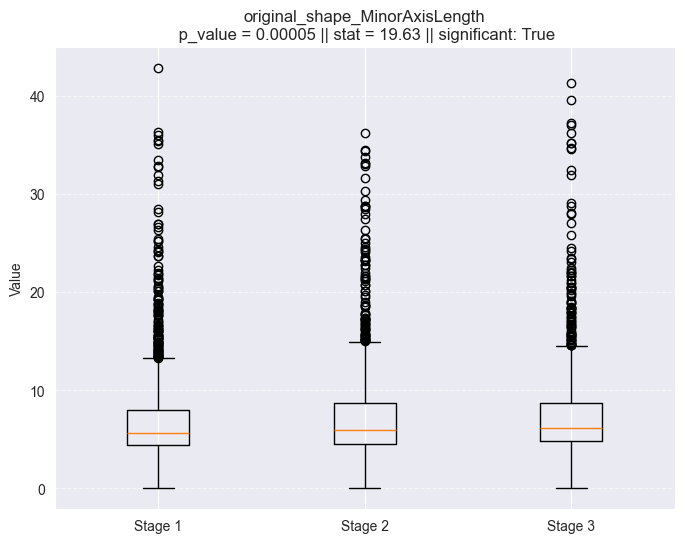

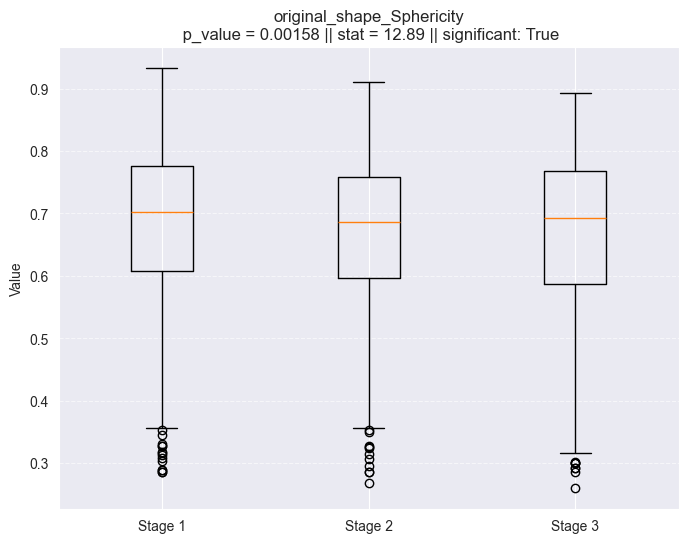

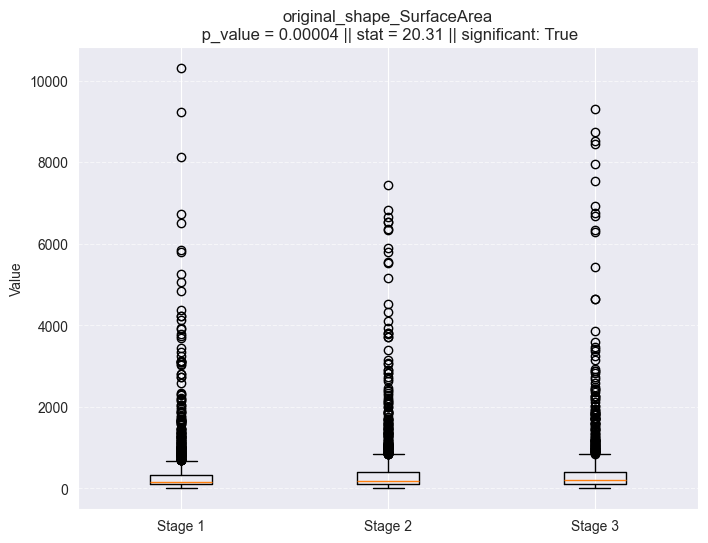

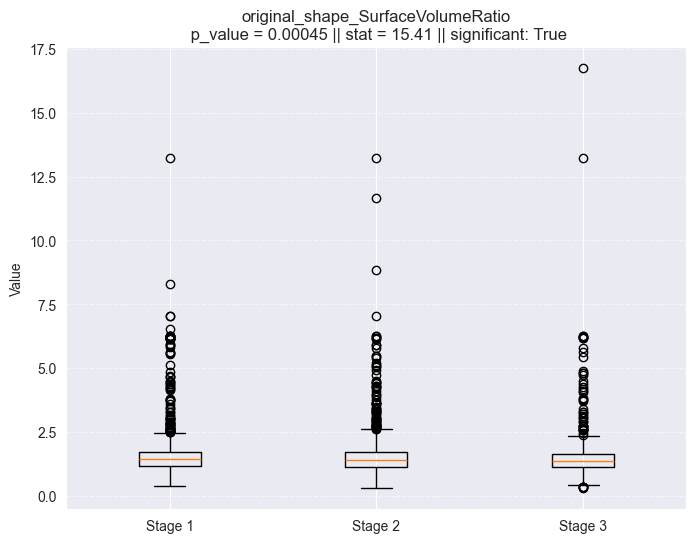

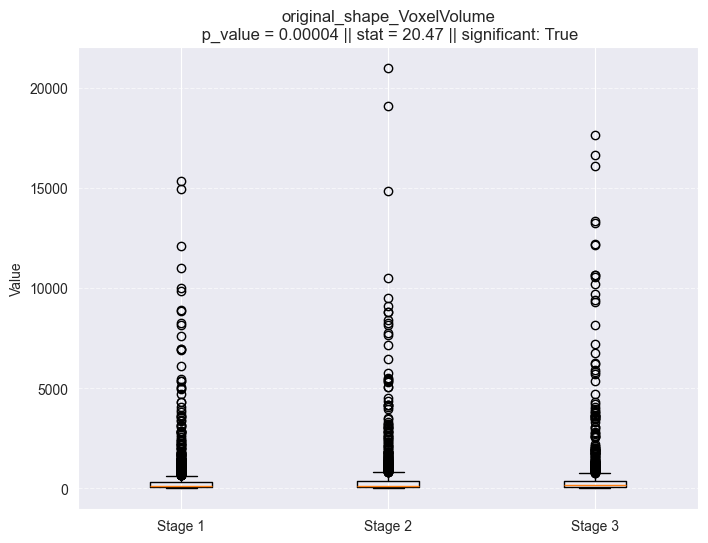

In [7]:
import matplotlib.pyplot as plt

for feature in df_stage_1:

    data_to_plot = [
        df_stage_1[feature].dropna(),
        df_stage_2[feature].dropna(),
        df_stage_3[feature].dropna()
    ]

    from scipy.stats import kruskal
    stat, p_value = kruskal(df_stage_1[feature].dropna(),  df_stage_2[feature].dropna(), df_stage_3[feature].dropna())

    plt.figure(figsize=(8, 6))
    plt.boxplot(data_to_plot, tick_labels=['Stage 1', 'Stage 2', 'Stage 3'])
    plt.title(f'{feature}\n p_value = {p_value:.5f} || stat = {stat:.2f} || significant: {p_value < 0.05}')
    plt.ylabel('Value')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# (Better visualization)

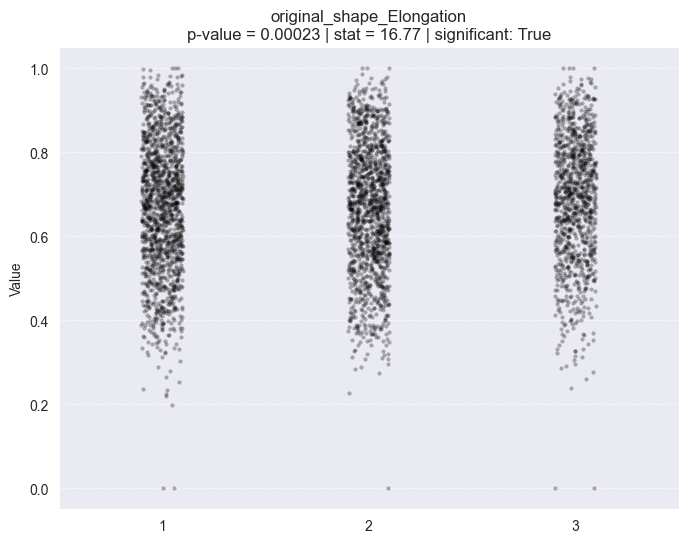

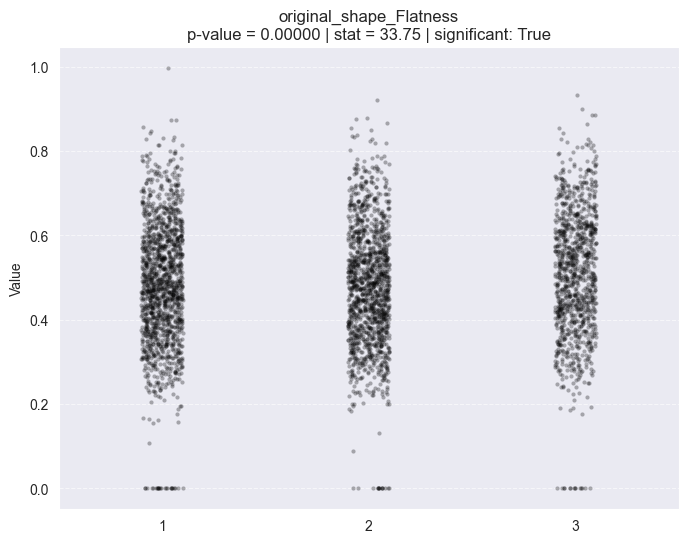

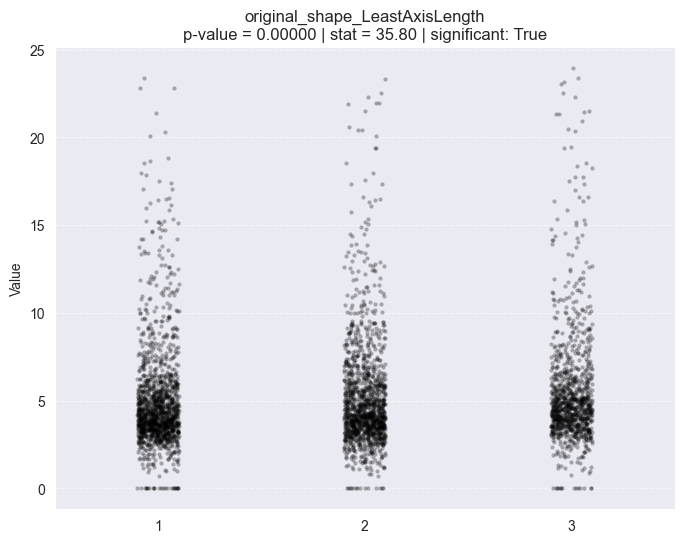

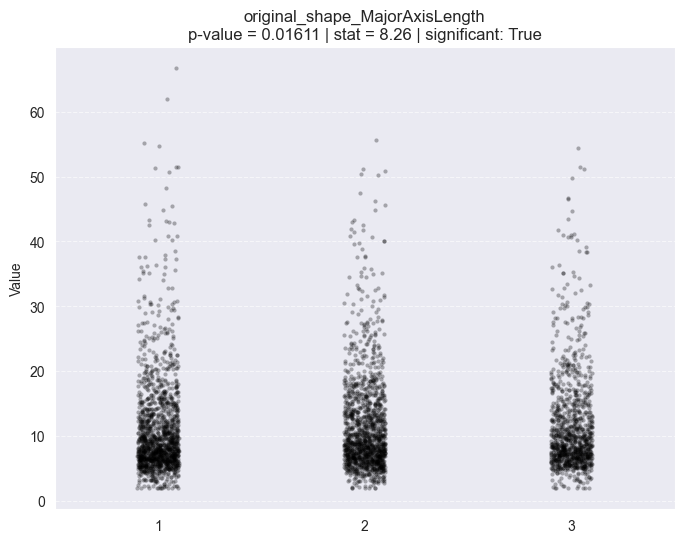

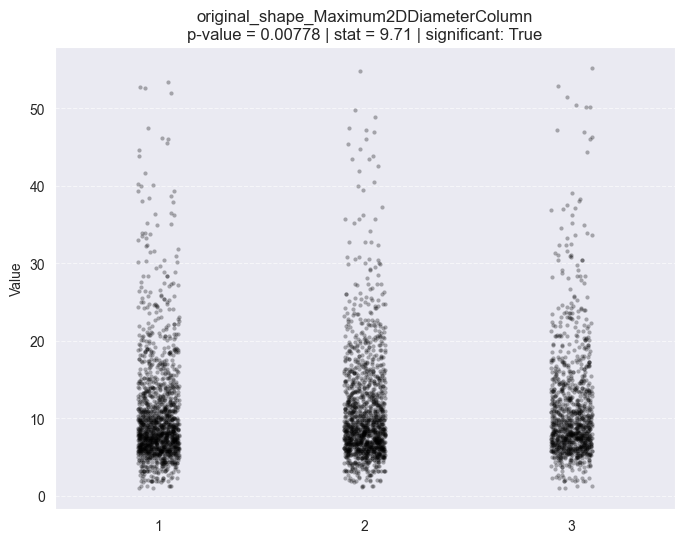

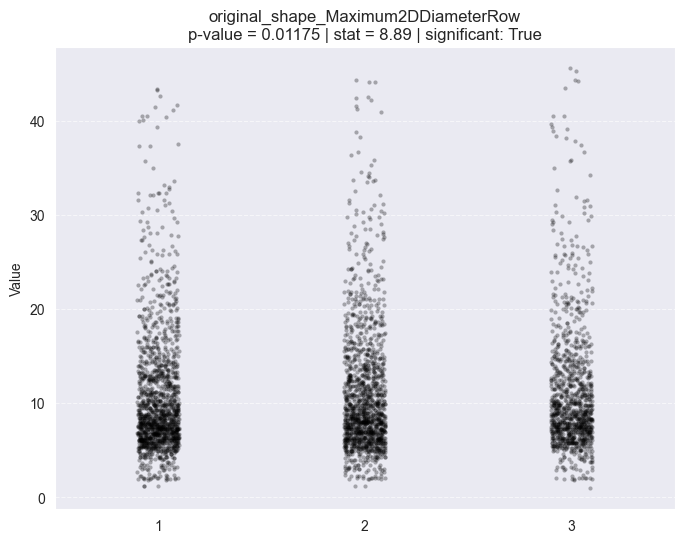

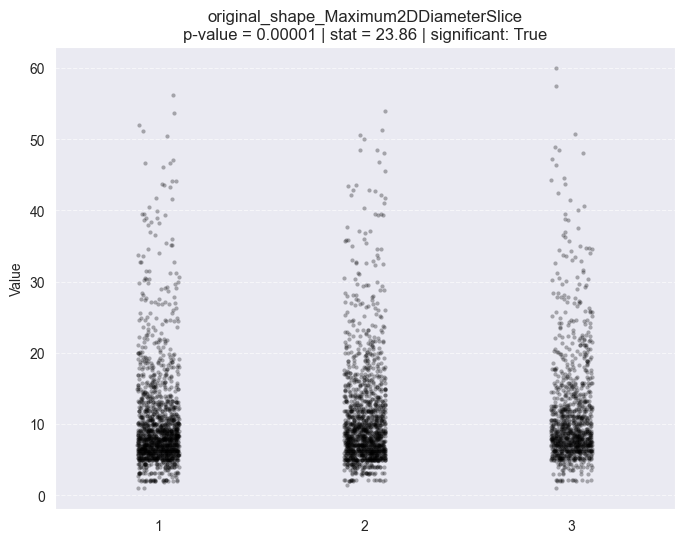

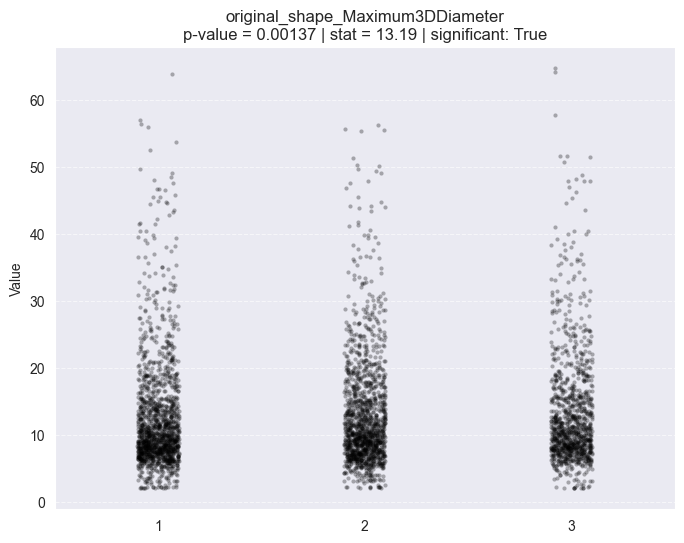

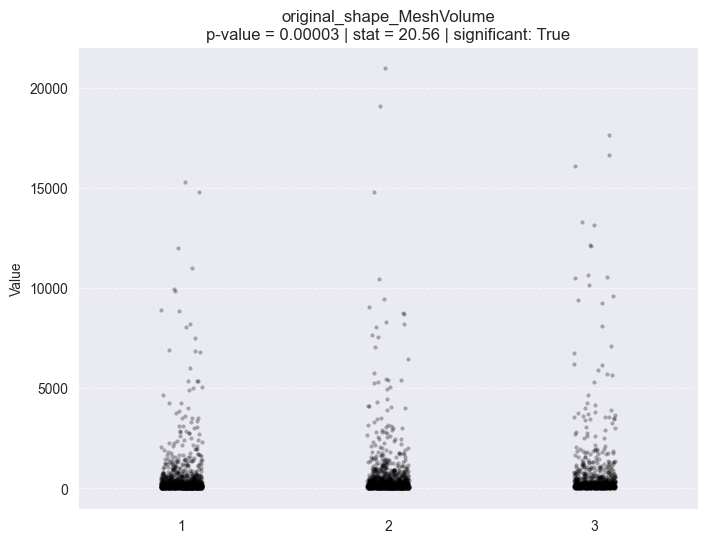

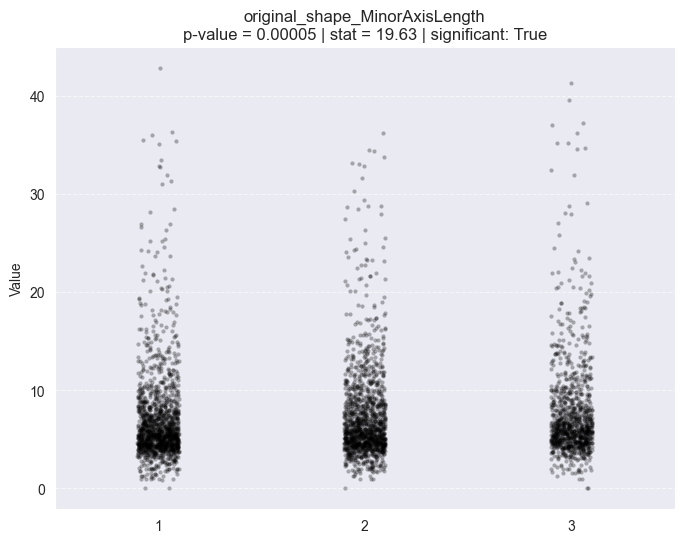

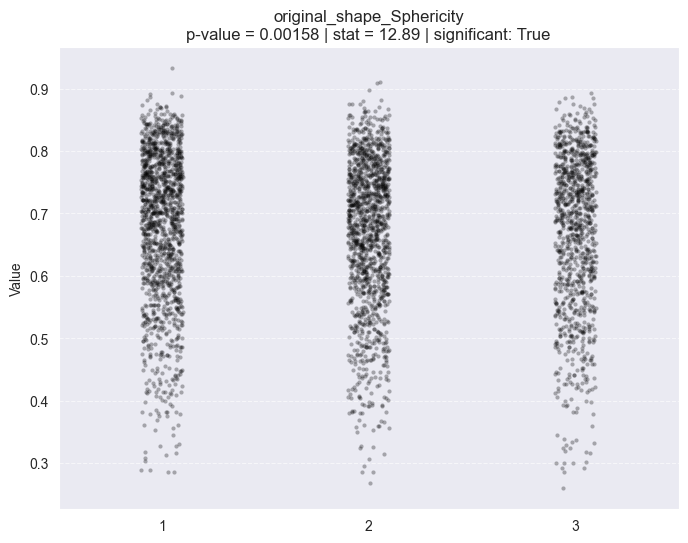

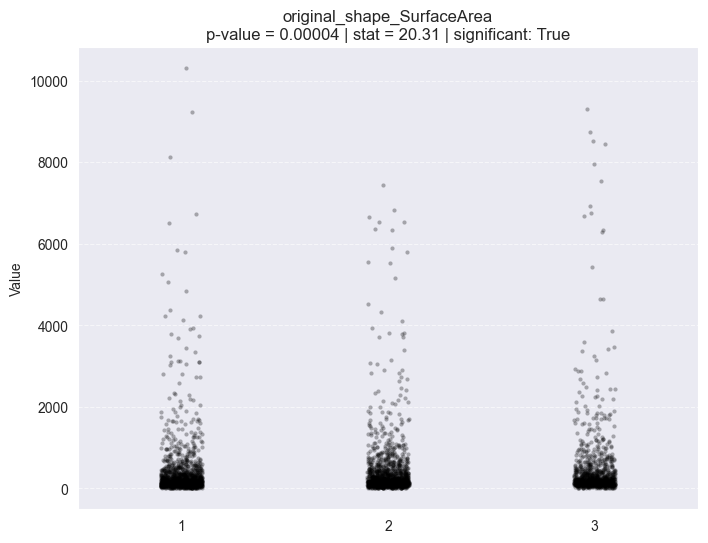

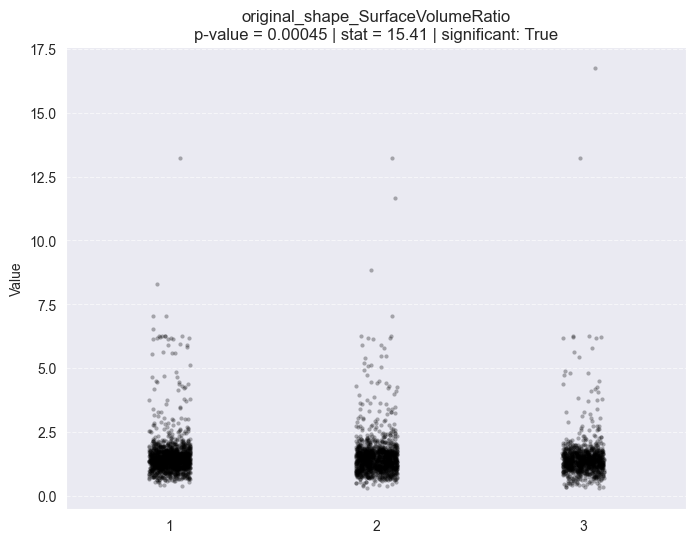

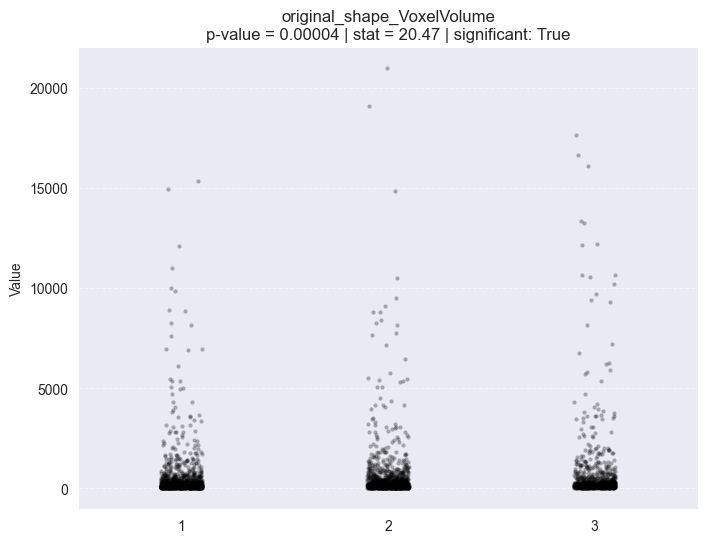

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

for feature in df_stage_1.columns:

    s1 = df_stage_1[feature].dropna()
    s2 = df_stage_2[feature].dropna()
    s3 = df_stage_3[feature].dropna()
    data_to_plot = [s1, s2, s3]

    from scipy.stats import kruskal
    stat, p_value = kruskal(s1, s2, s3)

    plt.figure(figsize=(8, 6))
    for i, d in enumerate(data_to_plot, start=1):
        sns.stripplot(x=[i]*len(d), y=d, color='black', alpha=0.3, size=3)

    plt.title(f'{feature}\np-value = {p_value:.5f} | stat = {stat:.2f} | significant: {p_value < 0.05}')
    plt.ylabel('Value')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# Počet compact/ellipse/flat lezi na štadium

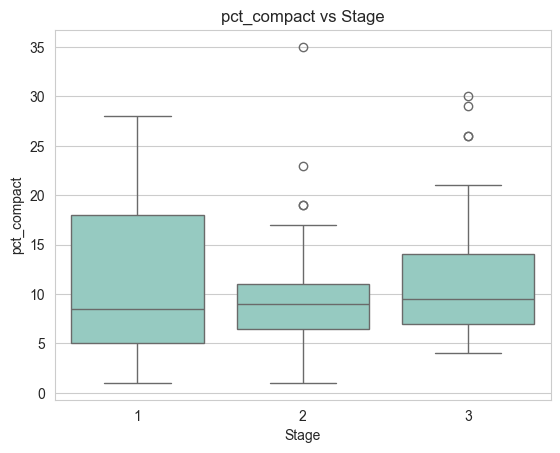

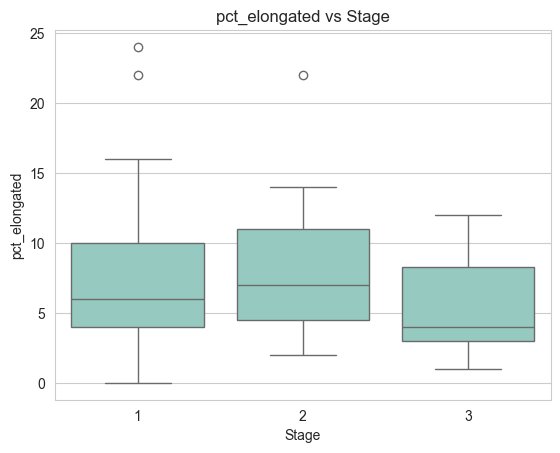

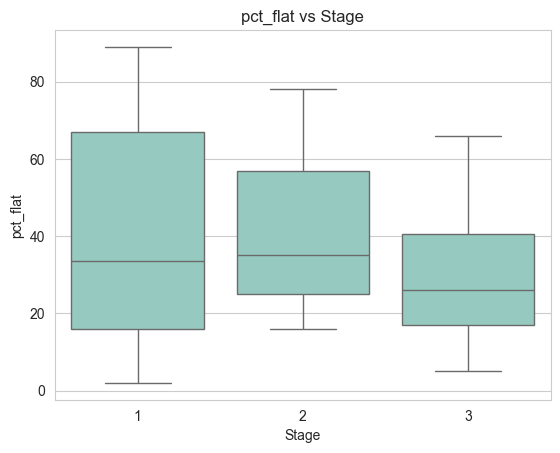

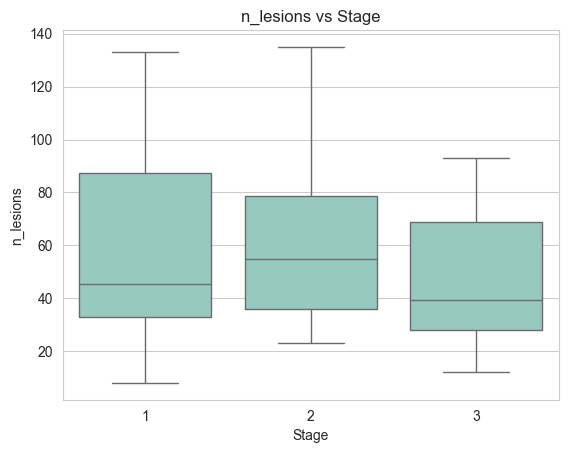

In [10]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def _shape_type(e, f):
    if e > 0.7 and f > 0.6:
        return "compact"
    elif e < 0.6 and f > 0.4:
        return "elongated"
    else:
        return "flat"


# FOR ALL PATIENTS
main_folder_path = r"E:\DATA_Myelomy"
all_patients = []

for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    df = pd.read_csv(csv_files[0]).filter(like="shape")

    E = df["original_shape_Elongation"]
    F = df["original_shape_Flatness"]

    lesion_shapes = [
        _shape_type(e, f) for e, f in zip(E, F) if not np.isnan(e) and not np.isnan(f)
    ]

    counts = pd.Series(lesion_shapes).value_counts()

    patient_features = {
        "patient_id": folder_name,
        "pct_compact": counts.get("compact", 0),
        "pct_elongated": counts.get("elongated", 0),
        "pct_flat": counts.get("flat", 0),
        "n_lesions": len(lesion_shapes)
    }

    all_patients.append(patient_features)

df_final = pd.DataFrame(all_patients)


pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1,'Stage 2': 2,'Stage 3': 3})

data = pd.merge(df_final, clinical_df[['Patient ID', 'Stage']], left_on='patient_id', right_on='Patient ID')
data.head()

features = ["pct_compact", "pct_elongated", "pct_flat", "n_lesions"]

for feature in features:
    sns.set_style("whitegrid")
    sns.boxplot(x='Stage', y=feature, data=data)
    plt.xlabel('Stage')
    plt.ylabel(feature)
    plt.title(f'{feature} vs Stage', fontsize=12)
    plt.show()
    print()

# Počet compact/ellipse/flat lezi pre M-protein type

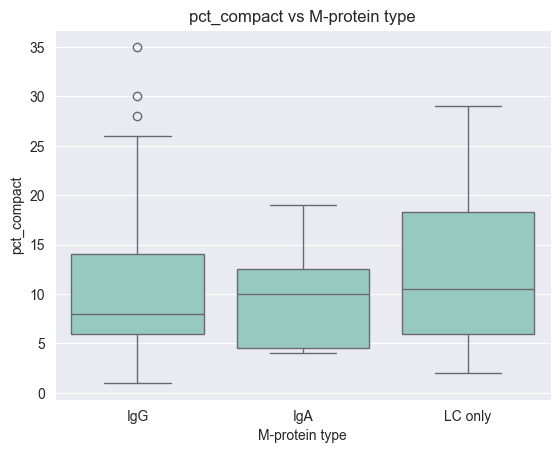

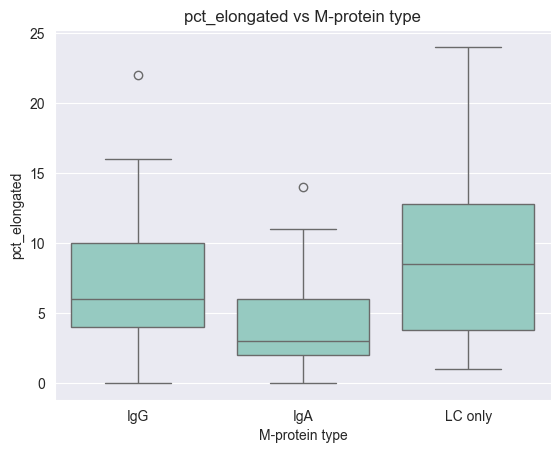

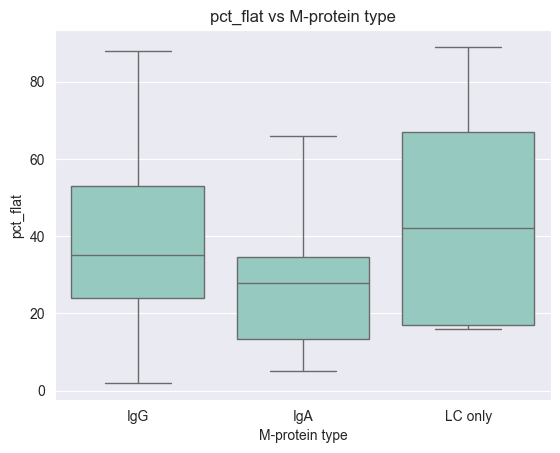

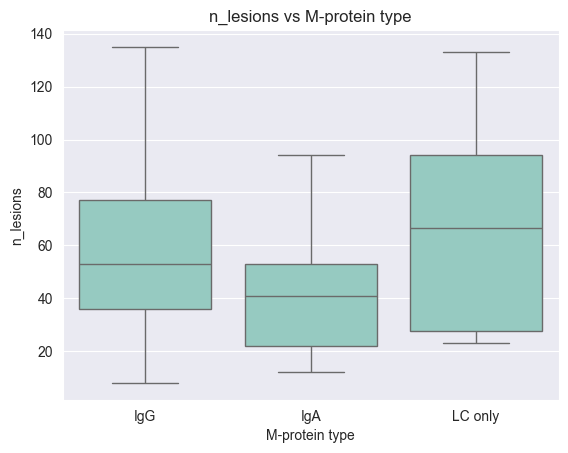

In [26]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def _shape_type(e, f):
    if e > 0.7 and f > 0.6:
        return "compact"
    elif e < 0.6 and f > 0.4:
        return "elongated"
    else:
        return "flat"


# FOR ALL PATIENTS
main_folder_path = r"E:\DATA_Myelomy"
all_patients = []

for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    df = pd.read_csv(csv_files[0]).filter(like="shape")

    E = df["original_shape_Elongation"]
    F = df["original_shape_Flatness"]

    lesion_shapes = [
        _shape_type(e, f) for e, f in zip(E, F) if not np.isnan(e) and not np.isnan(f)
    ]

    counts = pd.Series(lesion_shapes).value_counts()

    patient_features = {
        "patient_id": folder_name,
        "pct_compact": counts.get("compact", 0),
        "pct_elongated": counts.get("elongated", 0),
        "pct_flat": counts.get("flat", 0),
        "n_lesions": len(lesion_shapes)
    }

    all_patients.append(patient_features)

df_final = pd.DataFrame(all_patients)


pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")

data = pd.merge(df_final, clinical_df[['Patient ID', 'M-protein type']], left_on='patient_id', right_on='Patient ID')
data.head()

features = ["pct_compact", "pct_elongated", "pct_flat", "n_lesions"]

for feature in features:
    sns.set_style("darkgrid")
    sns.boxplot(x='M-protein type', y=feature, data=data)
    plt.xlabel('M-protein type')
    plt.ylabel(feature)
    plt.title(f'{feature} vs M-protein type', fontsize=12)
    plt.show()
    print()

# NEW FEATURES (ELONG X/Y/Z + FLAT X/Y/Z)

In [9]:
# RELATION BETWEEN SHAPE FEATURES AND CATEGORICAL FEATURES -> KRUSKAL-WALLIS TEST
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


main_folder_path = r"E:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*_elong_flat_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path)

    shape_features_stats = {"patient": folder_name}
    for col in df.columns:
        x = df[col].dropna()

        shape_features_stats[f"{col}_mean"]   = x.mean()
        shape_features_stats[f"{col}_median"] = x.median()
        shape_features_stats[f"{col}_std"]    = x.std()
        shape_features_stats[f"{col}_var"]    = x.var()
        shape_features_stats[f"{col}_cv"]     = x.std() / x.mean()     # coefficient of variation
        shape_features_stats[f"{col}_range"]  = x.max() - x.min()
        shape_features_stats[f"{col}_min"]    = x.min()
        shape_features_stats[f"{col}_max"]    = x.max()

        from scipy.stats import skew, kurtosis
        shape_features_stats[f"{col}_skewness"] = skew(x)
        shape_features_stats[f"{col}_kurtosis"] = kurtosis(x)

        shape_features_stats[f"{col}_percentile10"] = x.quantile(0.10)
        shape_features_stats[f"{col}_percentile25"] = x.quantile(0.25)
        shape_features_stats[f"{col}_percentile75"] = x.quantile(0.75)
        shape_features_stats[f"{col}_percentile90"] = x.quantile(0.90)
        shape_features_stats[f"{col}_IQR"] = x.quantile(0.75) - x.quantile(0.25)  # InterQuartileRange (P75-P25)

        hist, _ = np.histogram(x, bins=20)
        hist = hist / hist.sum()
        hist = hist[hist > 0]

        from scipy.stats import entropy
        shape_features_stats[f"{col}_entropy"] = entropy(hist)

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)


clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
merged_df = pd.merge(df_final, clinical_df, left_on='patient', right_on='Patient ID')

categoric_features_clinical = ["ISS classification", "M-protein type", "Light chain type"]
numeric_features_image = df_final.select_dtypes(include=['number']).columns

for clinical_col in categoric_features_clinical:

        if clinical_col not in merged_df.columns:
            continue

        kruskal_wallis = {}
        for radiomic_col in numeric_features_image:

            data_subset = merged_df[[radiomic_col, clinical_col]].dropna()

            groups = [group[radiomic_col].dropna().values for name, group in merged_df.groupby(clinical_col)]

            if len(groups) > 1:
                from scipy.stats import kruskal
                stat, p_value = kruskal(*groups)

                if p_value < 0.05:
                    kruskal_wallis[radiomic_col] = {'stat': stat, 'p_value': p_value}

        if kruskal_wallis:
            kruskal_wallis_df = pd.DataFrame(kruskal_wallis).T
            kruskal_wallis_df = kruskal_wallis_df.sort_values(by='stat', ascending=False)
            print(f"Results for {clinical_col}:")
            print(kruskal_wallis_df.head(15))
        else:
            print(f"No significant correlations for {clinical_col}")
        print("-" * 50)

Results for ISS classification:
                           stat   p_value
flat_x_percentile10   16.215797  0.000301
elong_x_percentile10  13.366895  0.001251
elong_z_std           12.517014  0.001914
elong_z_var           12.517014  0.001914
flat_x_percentile25   12.162370  0.002285
elong_x_percentile25  11.796083  0.002745
flat_z_var            10.443336  0.005398
flat_z_std            10.443336  0.005398
elong_z_max            9.075625  0.010697
elong_z_range          8.611483  0.013491
elong_z_mean           8.560897  0.013836
flat_z_mean            8.279968  0.015923
elong_z_median         8.238691  0.016255
flat_z_max             8.054266  0.017825
elong_z_cv             7.916754  0.019094
--------------------------------------------------
Results for M-protein type:
                    stat   p_value
flat_y_cv       7.071584  0.029136
flat_y_median   6.858142  0.032417
elong_y_median  6.423917  0.040278
--------------------------------------------------
Results for Light chain ty

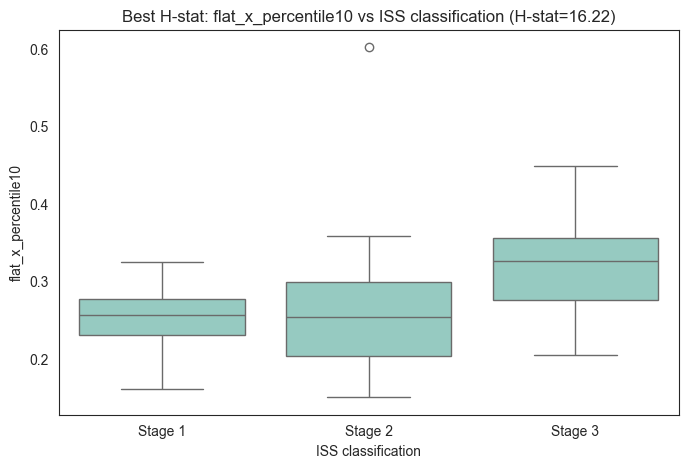

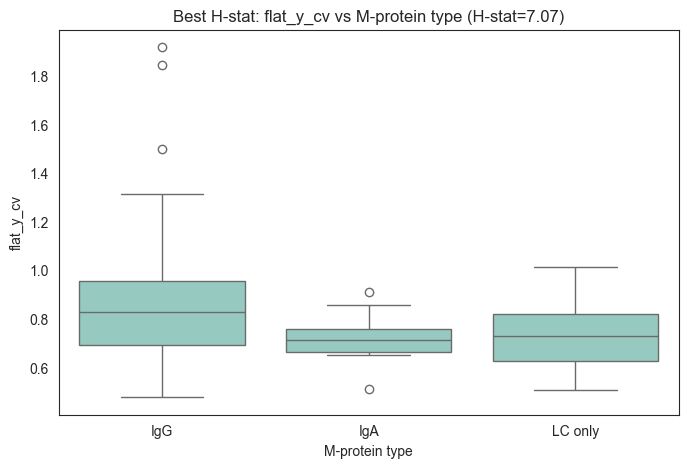

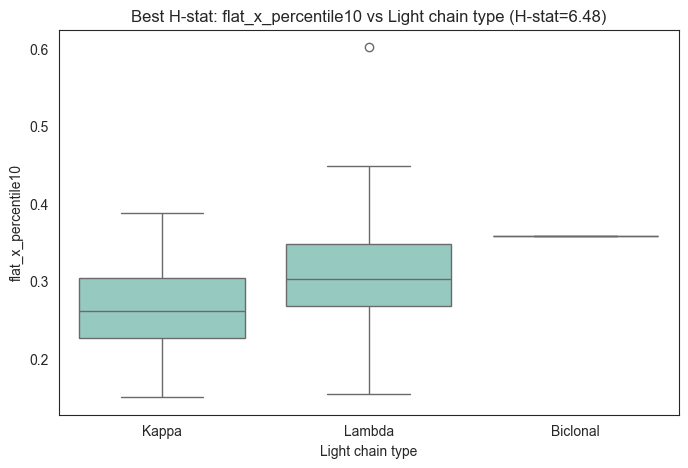

In [8]:
for clinical_col in categoric_features_clinical:
        if clinical_col not in merged_df.columns:
            continue

        best_radiomic = None
        final_stat_val = 0

        for radiomic_col in numeric_features_image:
            subset = merged_df[[radiomic_col, clinical_col]].dropna()

            # Use subset for the group calculation to ensure alignment
            groups = [group[radiomic_col].values for name, group in subset.groupby(clinical_col)]

            # Need at least two groups and data in them for Kruskal
            if len(groups) > 1:
                stat, p_value = kruskal(*groups)

                if p_value < 0.05 and stat > final_stat_val:
                    final_stat_val = stat # Update the statistic tracking
                    best_radiomic = radiomic_col

        # 2. Plotting the champion
        if best_radiomic:
            plt.figure(figsize=(8, 5))
            # FIX: Use merged_df, and the correct variable names
            sns.boxplot(data=merged_df, x=clinical_col, y=best_radiomic)

            # FIX: Changed 'Best Corr' to 'Best H-stat' to match Kruskal-Wallis output
            plt.title(f"Best H-stat: {best_radiomic} vs {clinical_col} (H-stat={final_stat_val:.2f})")
            plt.show()
            print()